In [1]:
# CELL 1 — Import Libraries & Load Hasil Query

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Style konsisten untuk semua chart — profesional & portofolio-ready
plt.rcParams.update({
    'figure.facecolor' : '#FAFAFA',
    'axes.facecolor'   : '#FAFAFA',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
    'font.family'      : 'sans-serif',
    'font.size'        : 11,
})

# Palet warna konsisten lintas chart
COLORS = ['#2563EB','#16A34A','#DC2626','#D97706',
          '#7C3AED','#0891B2','#DB2777','#65A30D']

# Load semua hasil query
q1 = pd.read_csv('../data/processed/q1_revenue_category_quarter.csv')
q2 = pd.read_csv('../data/processed/q2_payment_by_city.csv')
q3 = pd.read_csv('../data/processed/q3_store_performance.csv')
q4 = pd.read_csv('../data/processed/q4_discount_impact.csv')
q5 = pd.read_csv('../data/processed/q5_cancel_return_rate.csv')

import os
os.makedirs('../outputs/charts', exist_ok=True)

print("✓ Semua data loaded")

✓ Semua data loaded


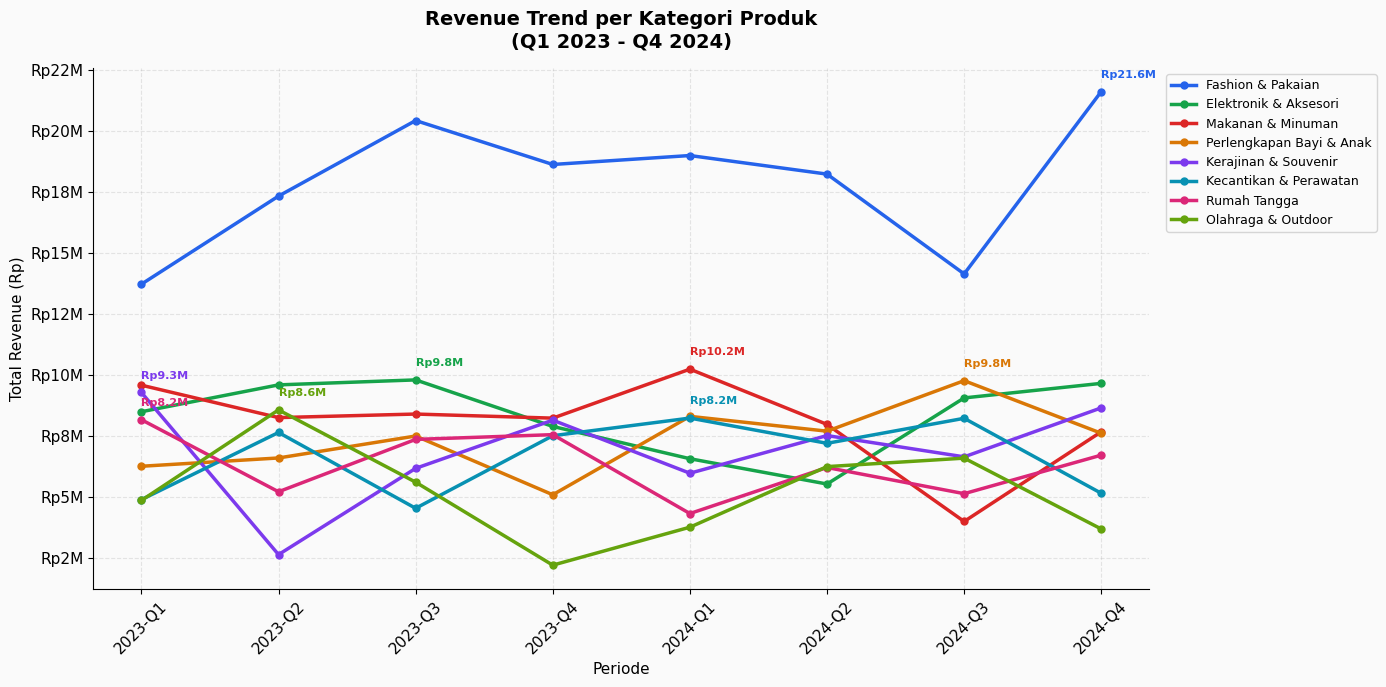

✓ Disimpan → 01_revenue_trend.png


In [ ]:
# CELL 2 — Chart 1: Revenue Trend per Kategori per Kuartal
# Pertanyaan bisnis:
#   "Kategori mana yang tumbuh vs stagnasi sepanjang 2023-2024?"

# --- Preprocessing ---
q1_plot = q1.dropna(subset=['tahun', 'kuartal', 'total_revenue']).copy()
q1_plot['tahun']   = q1_plot['tahun'].astype(int)
q1_plot['kuartal'] = q1_plot['kuartal'].astype(int)
q1_plot['period']  = q1_plot['tahun'].astype(str) + '-Q' + q1_plot['kuartal'].astype(str)

periods    = sorted(q1_plot['period'].unique())
categories = (q1_plot.groupby('category')['total_revenue']
              .sum()
              .sort_values(ascending=False)
              .index)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 7))

for i, cat in enumerate(categories):
    data = (q1_plot[q1_plot['category'] == cat]
            .set_index('period')
            .reindex(periods)['total_revenue']
            .fillna(0))

    ax.plot(periods, data.values,
            marker='o', linewidth=2.5,
            color=COLORS[i % len(COLORS)],
            label=cat, markersize=5)

    # Annotasi di titik tertinggi
    peak_idx = data.values.argmax()
    ax.annotate(
        f"Rp{data.values[peak_idx]/1e6:.1f}M",
        xy=(periods[peak_idx], data.values[peak_idx]),
        xytext=(0, 10), textcoords='offset points',
        fontsize=8, color=COLORS[i % len(COLORS)],
        fontweight='bold'
    )

ax.set_title('Revenue Trend per Kategori Produk\n(Q1 2023 - Q4 2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Periode', fontsize=11)
ax.set_ylabel('Total Revenue (Rp)', fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rp{x/1e6:.0f}M'))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/charts/01_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Disimpan → 01_revenue_trend.png")

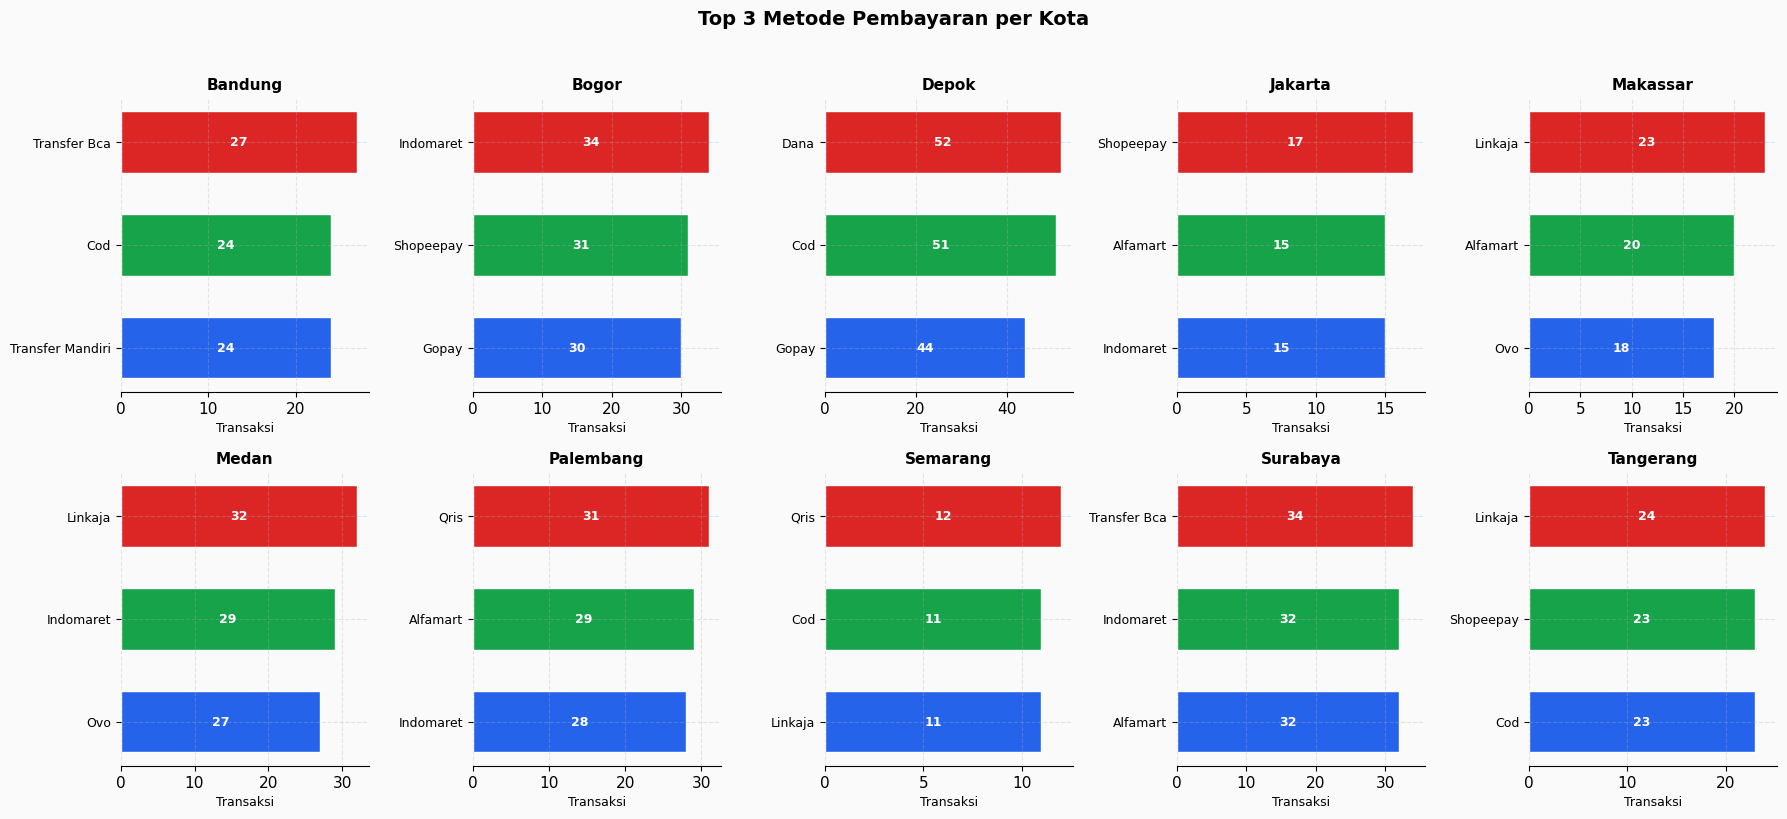

✓ Disimpan → 02_payment_by_city.png


In [4]:
# CELL 3 — Chart 2: Top 3 Metode Pembayaran per Kota
# -------------------------------------------------------------
# Pertanyaan bisnis:
#   "Apakah preferensi pembayaran berbeda antar kota?"

# --- Preprocessing ---
q2_plot = q2.dropna(subset=['city', 'payment_method']).copy()
top3    = (q2_plot
           .sort_values(['city', 'total_transaksi'], ascending=[True, False])
           .groupby('city')
           .head(3)
           .reset_index(drop=True))

cities = sorted(top3['city'].unique())

# --- Plot ---
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes      = axes.flatten()

for i, city in enumerate(cities):
    ax   = axes[i]
    data = (top3[top3['city'] == city]
            .sort_values('total_transaksi', ascending=True))

    bars = ax.barh(data['payment_method'], data['total_transaksi'],
                   color=COLORS[:len(data)], edgecolor='white', height=0.6)

    # Label nilai di dalam bar
    for bar in bars:
        w = bar.get_width()
        ax.text(w * 0.5, bar.get_y() + bar.get_height() / 2,
                f'{int(w):,}', va='center', ha='center',
                fontsize=9, color='white', fontweight='bold')

    ax.set_title(city, fontsize=11, fontweight='bold')
    ax.set_xlabel('Transaksi', fontsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.spines['left'].set_visible(False)

# Sembunyikan subplot kosong
for j in range(len(cities), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Top 3 Metode Pembayaran per Kota',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/charts/02_payment_by_city.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Disimpan → 02_payment_by_city.png")

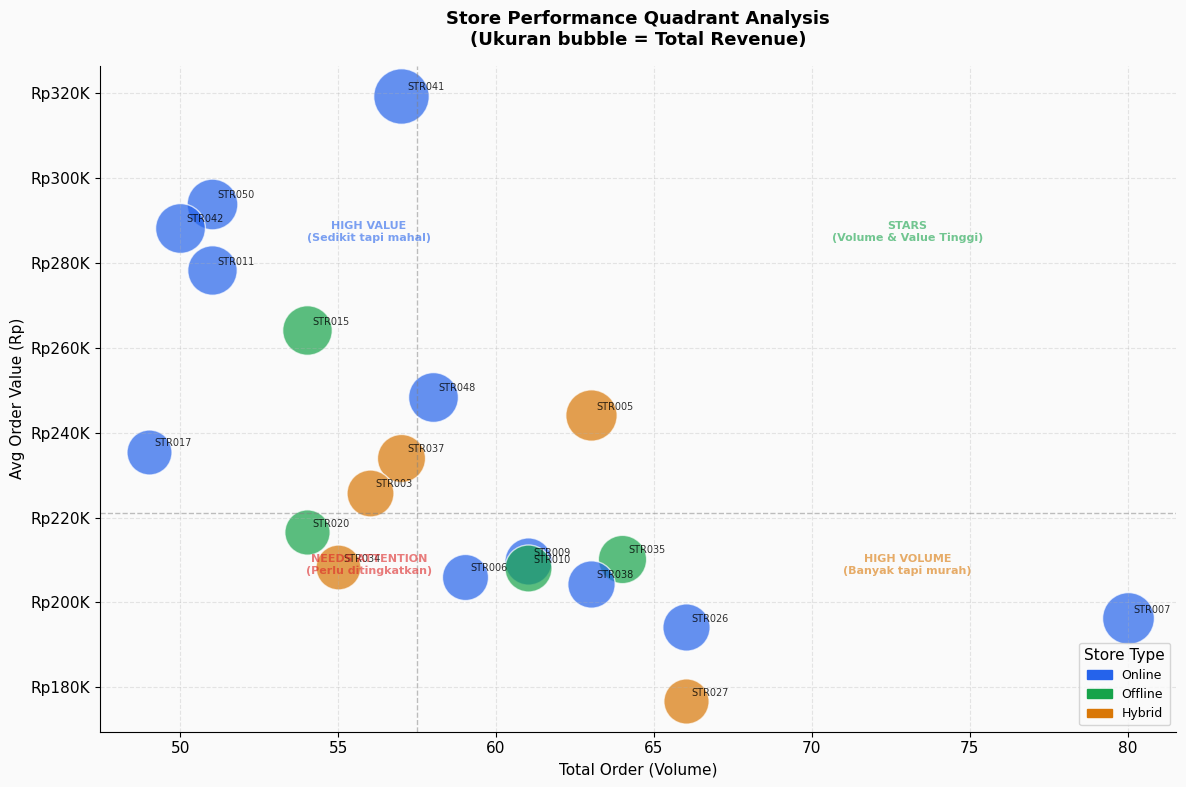

✓ Disimpan → 03_store_quadrant.png


In [5]:
# CELL 4 — Chart 3: Store Performance Quadrant Analysis
# -------------------------------------------------------------
# Pertanyaan bisnis:
#   "Toko mana yang high volume & high value sekaligus?"

q3_plot = q3.dropna(subset=['total_order', 'avg_order_value']).copy()

fig, ax = plt.subplots(figsize=(12, 8))

x_med = q3_plot['total_order'].median()
y_med = q3_plot['avg_order_value'].median()

type_colors = {'Online': '#2563EB', 'Offline': '#16A34A', 'Hybrid': '#D97706'}

for _, row in q3_plot.iterrows():
    color = type_colors.get(row['store_type'], '#6B7280')
    size  = (row['total_revenue'] / q3_plot['total_revenue'].max()) * 1500 + 100
    ax.scatter(row['total_order'], row['avg_order_value'],
               s=size, color=color, alpha=0.7,
               edgecolors='white', linewidth=1)
    ax.annotate(row['store_id'],
                (row['total_order'], row['avg_order_value']),
                xytext=(4, 4), textcoords='offset points',
                fontsize=7, alpha=0.8)

# Garis pembagi kuadran
ax.axvline(x_med, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(y_med, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Label kuadran
quad_labels = [
    (0.75, 0.75, 'STARS\n(Volume & Value Tinggi)',    '#16A34A'),
    (0.25, 0.75, 'HIGH VALUE\n(Sedikit tapi mahal)',   '#2563EB'),
    (0.75, 0.25, 'HIGH VOLUME\n(Banyak tapi murah)',   '#D97706'),
    (0.25, 0.25, 'NEEDS ATTENTION\n(Perlu ditingkatkan)', '#DC2626'),
]
for qx, qy, label, color in quad_labels:
    ax.text(qx, qy, label, transform=ax.transAxes,
            fontsize=8, color=color, alpha=0.6,
            ha='center', va='center', fontweight='bold')

legend_patches = [mpatches.Patch(color=c, label=t)
                  for t, c in type_colors.items()]
ax.legend(handles=legend_patches, title='Store Type',
          loc='lower right', fontsize=9)

ax.set_title('Store Performance Quadrant Analysis\n(Ukuran bubble = Total Revenue)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Total Order (Volume)', fontsize=11)
ax.set_ylabel('Avg Order Value (Rp)', fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rp{x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('../outputs/charts/03_store_quadrant.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Disimpan → 03_store_quadrant.png")

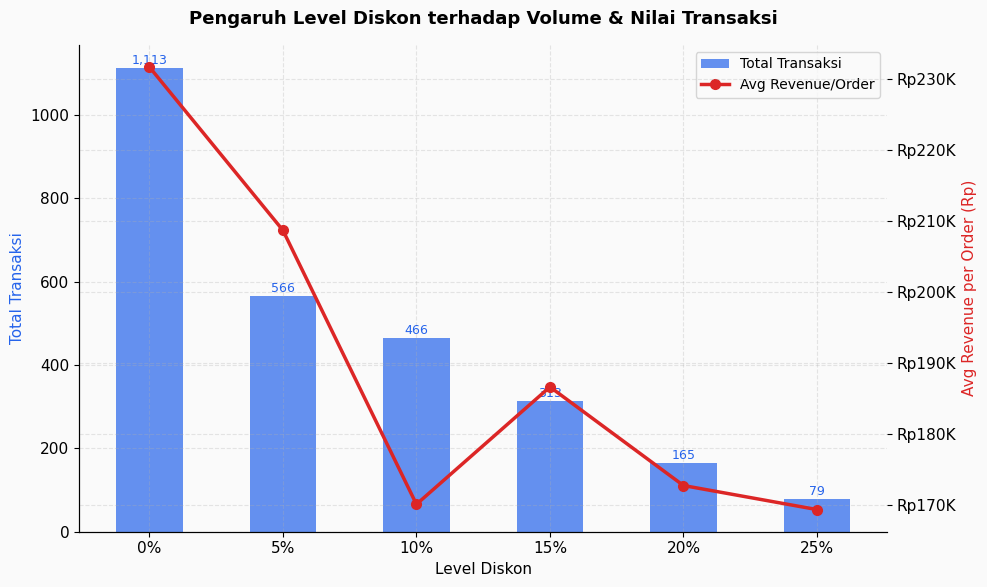

✓ Disimpan → 04_discount_impact.png


In [6]:
# CELL 5 — Chart 4: Pengaruh Diskon terhadap Volume & Nilai
# -------------------------------------------------------------
# Pertanyaan bisnis:
#   "Di level diskon berapa sweet spot volume tertinggi
#    tanpa mengorbankan avg revenue per order?"

q4_plot = q4.dropna(subset=['discount_pct', 'total_transaksi']).copy()
q4_plot = q4_plot.sort_values('discount_pct').reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2      = ax1.twinx()

x    = np.arange(len(q4_plot))
bars = ax1.bar(x, q4_plot['total_transaksi'],
               color='#2563EB', alpha=0.7,
               label='Total Transaksi', width=0.5)
line, = ax2.plot(x, q4_plot['avg_revenue_per_order'],
                 color='#DC2626', marker='o',
                 linewidth=2.5, markersize=7,
                 label='Avg Revenue/Order')

# Label nilai di atas bar
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 2,
             f'{int(bar.get_height()):,}',
             ha='center', va='bottom',
             fontsize=9, color='#2563EB')

ax1.set_xticks(x)
ax1.set_xticklabels([f'{int(d)}%' for d in q4_plot['discount_pct']])
ax1.set_xlabel('Level Diskon', fontsize=11)
ax1.set_ylabel('Total Transaksi', fontsize=11, color='#2563EB')
ax2.set_ylabel('Avg Revenue per Order (Rp)', fontsize=11, color='#DC2626')
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rp{x/1e3:.0f}K'))

# Gabungkan legend dua axis
ax1.legend([bars, line],
           ['Total Transaksi', 'Avg Revenue/Order'],
           loc='upper right', fontsize=10)

ax1.set_title('Pengaruh Level Diskon terhadap Volume & Nilai Transaksi',
              fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../outputs/charts/04_discount_impact.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Disimpan → 04_discount_impact.png")

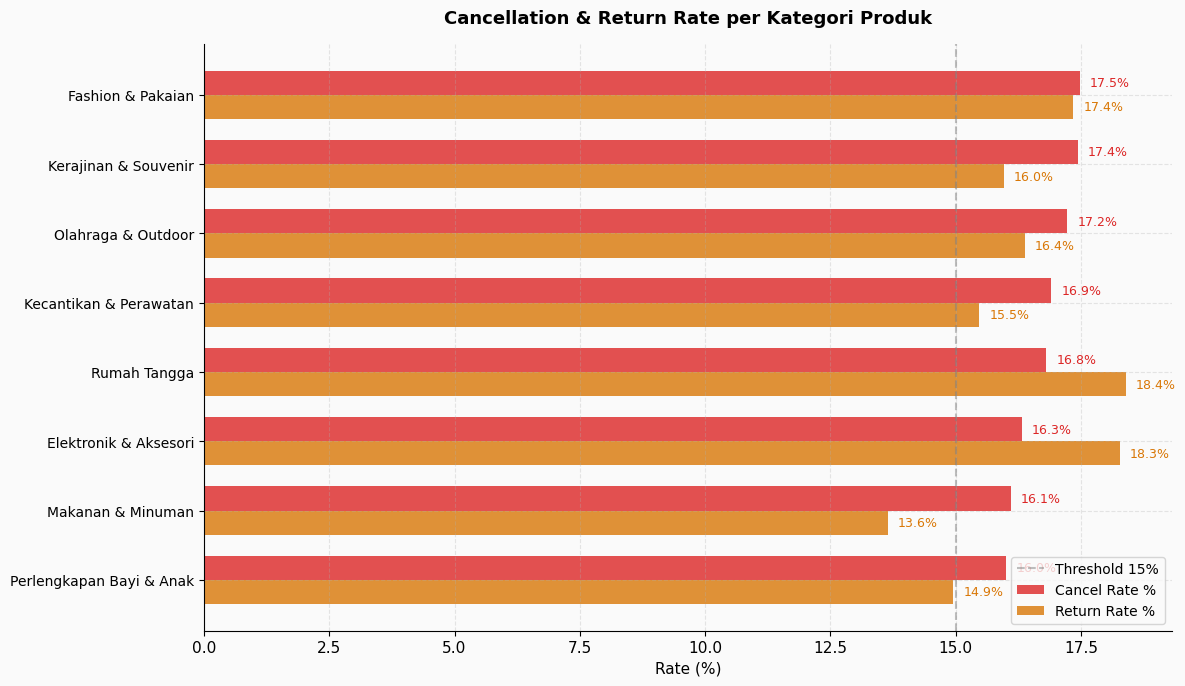

✓ Disimpan → 05_cancel_return_rate.png


In [7]:
# CELL 6 — Chart 5: Cancellation & Return Rate per Kategori
# -------------------------------------------------------------
# Pertanyaan bisnis:
#   "Kategori mana yang paling berisiko secara operasional
#    dan perlu perhatian manajemen segera?"

q5_plot = q5.dropna(subset=['cancel_rate_pct', 'return_rate_pct']).copy()
q5_plot = q5_plot.sort_values('cancel_rate_pct', ascending=True).reset_index(drop=True)

y      = np.arange(len(q5_plot))
height = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.barh(y + height / 2, q5_plot['cancel_rate_pct'],
                height=height, color='#DC2626',
                alpha=0.8, label='Cancel Rate %')
bars2 = ax.barh(y - height / 2, q5_plot['return_rate_pct'],
                height=height, color='#D97706',
                alpha=0.8, label='Return Rate %')

# Label nilai
for bar in bars1:
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}%',
            va='center', fontsize=9, color='#DC2626')
for bar in bars2:
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}%',
            va='center', fontsize=9, color='#D97706')

# Threshold warning
ax.axvline(15, color='gray', linestyle='--',
           alpha=0.5, linewidth=1.5, label='Threshold 15%')

ax.set_yticks(y)
ax.set_yticklabels(q5_plot['category'], fontsize=10)
ax.set_xlabel('Rate (%)', fontsize=11)
ax.set_title('Cancellation & Return Rate per Kategori Produk',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/05_cancel_return_rate.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Disimpan → 05_cancel_return_rate.png")

In [8]:
# CELL 7 — Executive Summary

top_cat      = q1_plot.groupby('category')['total_revenue'].sum().idxmax()
top_revenue  = q1_plot.groupby('category')['total_revenue'].sum().max()
top_payment  = q2.groupby('payment_method')['total_transaksi'].sum().idxmax()
high_cancel  = q5_plot.sort_values('cancel_rate_pct', ascending=False).iloc[0]
high_return  = q5_plot.sort_values('return_rate_pct',  ascending=False).iloc[0]
best_disc    = q4_plot.loc[q4_plot['total_transaksi'].idxmax(), 'discount_pct']
top_store    = q3_plot.sort_values('total_revenue', ascending=False).iloc[0]

print("=" * 62)
print("      EXECUTIVE SUMMARY — UMKM RETAIL ANALYSIS")
print("      Periode: Jan 2023 – Des 2024")
print("=" * 62)
print(f"""
1. REVENUE
   Kategori terbaik  : {top_cat}
   Total revenue     : Rp{top_revenue:,.0f}

2. PEMBAYARAN
   Metode terpopuler : {top_payment}
   Rekomendasi       : Prioritaskan promo berbasis {top_payment}
                       di semua kota

3. PERFORMA TOKO
   Top store         : {top_store['store_name']} ({top_store['city']})
   Revenue           : Rp{top_store['total_revenue']:,.0f}
   Store type        : {top_store['store_type']}

4. RISIKO OPERASIONAL
   Cancel rate tinggi: {high_cancel['category']}
                       ({high_cancel['cancel_rate_pct']:.1f}%)
   Return rate tinggi: {high_return['category']}
                       ({high_return['return_rate_pct']:.1f}%)
   Rekomendasi       : Audit SOP & deskripsi produk
                       kategori tersebut

5. STRATEGI DISKON
   Sweet spot        : Diskon {int(best_disc)}%
   Rekomendasi       : Fokuskan flash sale di level ini
                       untuk maksimalkan volume transaksi

PRIORITAS AKSI:
  [HIGH]   Skalakan {top_cat} — kontributor revenue utama
  [MEDIUM] Audit kategori {high_cancel['category']} — cancel rate tinggi
  [LOW]    Standarisasi promo {top_payment} lintas kota
""")
print("=" * 62)

      EXECUTIVE SUMMARY — UMKM RETAIL ANALYSIS
      Periode: Jan 2023 – Des 2024

1. REVENUE
   Kategori terbaik  : Fashion & Pakaian
   Total revenue     : Rp143,210,335

2. PEMBAYARAN
   Metode terpopuler : Indomaret
   Rekomendasi       : Prioritaskan promo berbasis Indomaret
                       di semua kota

3. PERFORMA TOKO
   Top store         : Toko Makmur Semarang (Semarang)
   Revenue           : Rp18,205,930
   Store type        : Online

4. RISIKO OPERASIONAL
   Cancel rate tinggi: Fashion & Pakaian
                       (17.5%)
   Return rate tinggi: Rumah Tangga
                       (18.4%)
   Rekomendasi       : Audit SOP & deskripsi produk
                       kategori tersebut

5. STRATEGI DISKON
   Sweet spot        : Diskon 0%
   Rekomendasi       : Fokuskan flash sale di level ini
                       untuk maksimalkan volume transaksi

PRIORITAS AKSI:
  [HIGH]   Skalakan Fashion & Pakaian — kontributor revenue utama
  [MEDIUM] Audit kategori Fashion & Pa

In [11]:
# CELL 8 — Verifikasi Output Chart

charts = [
    '../outputs/charts/01_revenue_trend.png',
    '../outputs/charts/02_payment_by_city.png',
    '../outputs/charts/03_store_quadrant.png',
    '../outputs/charts/04_discount_impact.png',
    '../outputs/charts/05_cancel_return_rate.png',
]

print("OUTPUT CHARTS:")
for f in charts:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) // 1024
        print(f"  ✓ {os.path.basename(f):42s} {size_kb:4d} KB")
    else:
        print(f"  ✗ {os.path.basename(f)} — TIDAK DITEMUKAN")


OUTPUT CHARTS:
  ✓ 01_revenue_trend.png                        251 KB
  ✓ 02_payment_by_city.png                      133 KB
  ✓ 03_store_quadrant.png                       175 KB
  ✓ 04_discount_impact.png                      114 KB
  ✓ 05_cancel_return_rate.png                   115 KB


In [12]:
# CELL TAMBAHAN — Ekstrak Angka untuk README

total_orders   = q1_plot['total_order'].sum()
total_revenue  = q1_plot['total_revenue'].sum()
total_kategori = q1_plot['category'].nunique()
top_cat        = q1_plot.groupby('category')['total_revenue'].sum().idxmax()
top_cat_rev    = q1_plot.groupby('category')['total_revenue'].sum().max()
top_payment    = q2.groupby('payment_method')['total_transaksi'].sum().idxmax()
top_payment_n  = q2.groupby('payment_method')['total_transaksi'].sum().max()
high_cancel    = q5_plot.sort_values('cancel_rate_pct', ascending=False).iloc[0]
best_disc      = int(q4_plot.loc[q4_plot['total_transaksi'].idxmax(), 'discount_pct'])
total_stores   = q3_plot['store_id'].nunique()
top_store      = q3_plot.sort_values('total_revenue', ascending=False).iloc[0]

print(f"total_orders   = {total_orders:,}")
print(f"total_revenue  = Rp{total_revenue:,.0f}")
print(f"total_kategori = {total_kategori}")
print(f"top_cat        = {top_cat}")
print(f"top_cat_rev    = Rp{top_cat_rev:,.0f}")
print(f"top_payment    = {top_payment} ({top_payment_n:,} transaksi)")
print(f"high_cancel    = {high_cancel['category']} ({high_cancel['cancel_rate_pct']:.1f}%)")
print(f"best_disc      = {best_disc}%")
print(f"total_stores   = {total_stores}")
print(f"top_store      = {top_store['store_name']} - Rp{top_store['total_revenue']:,.0f}")

total_orders   = 2,624
total_revenue  = Rp533,899,790
total_kategori = 8
top_cat        = Fashion & Pakaian
top_cat_rev    = Rp143,210,335
top_payment    = Indomaret (228 transaksi)
high_cancel    = Fashion & Pakaian (17.5%)
best_disc      = 0%
total_stores   = 20
top_store      = Toko Makmur Semarang - Rp18,205,930
